In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("Nassau Candy Distributor.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 10194
Columns: 18


In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [10]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='str')

In [11]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d-%m-%Y'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d-%m-%Y'
)

print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [12]:
df['Lead Time'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [13]:
df['Lead Time'].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64

In [14]:
df[['Order Date', 'Ship Date', 'Lead Time']].head(10)

,Order Date,Ship Date,Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912
5,2024-01-06,2026-07-03,909
6,2024-01-06,2026-07-03,909
7,2024-01-06,2026-06-30,906
8,2024-01-06,2026-07-03,909
9,2024-01-06,2026-07-03,909


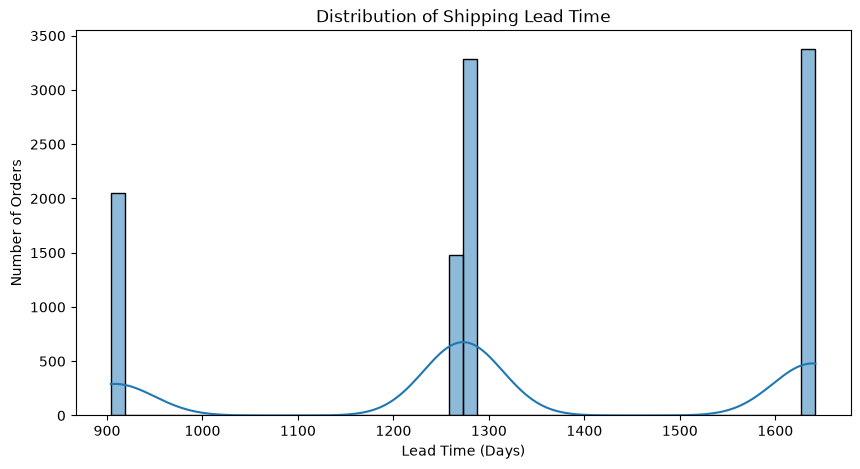

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['Lead Time'],
    bins=50,
    kde=True
)

plt.title('Distribution of Shipping Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Orders')

plt.show()

In [16]:
df['Lead Time'].value_counts().sort_index().head(30)

Lead Time
904       89
905       40
906      289
907      176
908      591
909      519
910      207
911      134
912        4
915        2
1269     258
1270     156
1271     610
1272     456
1273    1326
1274    1035
1275     612
1276     293
1277      18
1634       3
1635     179
1636     190
1637     449
1638     411
1639     896
1640     657
1641     397
1642     197
Name: count, dtype: int64

In [17]:
# checking for null values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
Lead Time         0
dtype: int64

In [18]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [19]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [20]:
print("Minimum Lead Time:", df['Lead Time'].min())
print("Maximum Lead Time:", df['Lead Time'].max())

print("\nLead Time Quantiles:")
print(df['Lead Time'].quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1]))

Minimum Lead Time: 904
Maximum Lead Time: 1642

Lead Time Quantiles:
0.00     904.0
0.01     905.0
0.05     907.0
0.25    1271.0
0.50    1274.0
0.75    1638.0
0.95    1641.0
0.99    1642.0
1.00    1642.0
Name: Lead Time, dtype: float64


In [21]:
df[['Order Date', 'Ship Date', 'Lead Time']].sort_values(
    'Lead Time'
).head(20)

,Order Date,Ship Date,Lead Time
1729,2024-11-26,2027-05-19,904
1696,2024-11-24,2027-05-17,904
1732,2024-11-28,2027-05-21,904
454,2024-05-09,2026-10-30,904
455,2024-05-09,2026-10-30,904
456,2024-05-09,2026-10-30,904
424,2024-05-02,2026-10-23,904
429,2024-05-04,2026-10-25,904
538,2024-05-27,2026-11-17,904
540,2024-05-27,2026-11-17,904


In [22]:
df[['Order Date', 'Ship Date', 'Lead Time']].sort_values(
    'Lead Time'
).tail(20)

,Order Date,Ship Date,Lead Time
8026,2025-07-01,2029-12-29,1642
8330,2025-08-13,2030-02-10,1642
8030,2025-07-03,2029-12-31,1642
8032,2025-07-03,2029-12-31,1642
8071,2025-07-08,2030-01-05,1642
8351,2025-08-17,2030-02-14,1642
7094,2025-03-03,2029-08-31,1642
9731,2025-12-01,2030-05-31,1642
9540,2025-11-19,2030-05-19,1642
10160,2025-12-28,2030-06-27,1642


In [23]:
df['Lead Time Group'] = pd.cut(
    df['Lead Time'],
    bins=[0, 1000, 1400, 1800, float('inf')],
    labels=[
        'Group 1: <1000 days',
        'Group 2: 1000-1400 days',
        'Group 3: 1400-1800 days',
        'Group 4: >1800 days'
    ]
)

print(df['Lead Time Group'].value_counts())

Lead Time Group
Group 2: 1000-1400 days    4764
Group 3: 1400-1800 days    3379
Group 1: <1000 days        2051
Group 4: >1800 days           0
Name: count, dtype: int64


In [24]:
df['Order Year'] = df['Order Date'].dt.year
df['Ship Year'] = df['Ship Date'].dt.year

pd.crosstab(
    df['Order Year'],
    df['Ship Year']
)

Ship Year,2026,2027,2028,2029,2030
Order Year,,,,,
2024,711,2089,1381,0,0
2025,0,0,986,2899,2128


In [25]:
df.groupby(
    ['Order Year', 'Ship Year']
).agg(
    Orders=('Order ID', 'count'),
    Avg_Lead_Time=('Lead Time', 'mean'),
    Min_Lead_Time=('Lead Time', 'min'),
    Max_Lead_Time=('Lead Time', 'max')
).reset_index()

,Order Year,Ship Year,Orders,Avg_Lead_Time,Min_Lead_Time,Max_Lead_Time
0,2024,2026,711,908.195499,904,912
1,2024,2027,2089,1038.966012,904,1277
2,2024,2028,1381,1272.964518,1269,1276
3,2025,2028,986,1272.738337,1269,1276
4,2025,2029,2899,1430.843049,1269,1642
5,2025,2030,2128,1638.927162,1635,1642


In [27]:
df.groupby(
    ['Order Year', 'Ship Year']
).agg(
    Orders=('Order ID', 'count'),
    Avg_Lead_Time=('Lead Time', 'mean'),
    Min_Lead_Time=('Lead Time', 'min'),
    Max_Lead_Time=('Lead Time', 'max')
).reset_index()

,Order Year,Ship Year,Orders,Avg_Lead_Time,Min_Lead_Time,Max_Lead_Time
0,2024,2026,711,908.195499,904,912
1,2024,2027,2089,1038.966012,904,1277
2,2024,2028,1381,1272.964518,1269,1276
3,2025,2028,986,1272.738337,1269,1276
4,2025,2029,2899,1430.843049,1269,1642
5,2025,2030,2128,1638.927162,1635,1642


In [28]:
analysis_df = df.copy()

print("Analysis dataset shape:", analysis_df.shape)

Analysis dataset shape: (10194, 22)


In [29]:
quality_check = pd.DataFrame({
    'Missing Values': analysis_df.isnull().sum(),
    'Missing %': (analysis_df.isnull().sum() / len(analysis_df) * 100).round(2),
    'Unique Values': analysis_df.nunique()
})

quality_check

,Missing Values,Missing %,Unique Values
Row ID,0,0.0,10194
Order ID,0,0.0,8549
Order Date,0,0.0,717
Ship Date,0,0.0,1338
Ship Mode,0,0.0,4
Customer ID,0,0.0,5044
Country/Region,0,0.0,2
City,0,0.0,542
State/Province,0,0.0,59
Postal Code,0,0.0,654


In [30]:
duplicate_count = analysis_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [31]:
numeric_columns = [
    'Sales',
    'Units',
    'Gross Profit',
    'Cost',
    'Lead Time'
]

for column in numeric_columns:
    print(f"\n{column}")
    print("Minimum:", analysis_df[column].min())
    print("Zero values:", (analysis_df[column] == 0).sum())
    print("Negative values:", (analysis_df[column] < 0).sum())


Sales
Minimum: 1.25
Zero values: 0
Negative values: 0

Units
Minimum: 1
Zero values: 0
Negative values: 0

Gross Profit
Minimum: 0.25
Zero values: 0
Negative values: 0

Cost
Minimum: 0.6
Zero values: 0
Negative values: 0

Lead Time
Minimum: 904
Zero values: 0
Negative values: 0


In [32]:
analysis_df[
    ['Sales', 'Units', 'Gross Profit', 'Cost', 'Lead Time']
].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,10194.0,13.908537,11.341020,1.25,7.2,10.80,18.00,260.0
Units,10194.0,3.791838,2.228317,1.00,2.0,3.00,5.00,14.0
Gross Profit,10194.0,9.166451,6.643740,0.25,4.9,7.47,12.25,130.0
Cost,10194.0,4.742087,5.061647,0.60,2.4,3.60,5.70,130.0
Lead Time,10194.0,1320.841868,262.444892,904.00,1271.0,1274.00,1638.00,1642.0


In [34]:
analysis_df['Profit Margin %'] = np.where(
    analysis_df['Sales'] != 0,
    (analysis_df['Gross Profit'] / analysis_df['Sales']) * 100,
    0
)

In [35]:
'Profit Margin %' in analysis_df.columns

True

In [36]:
analysis_df['Profit Margin %'].describe()

count    10194.000000
mean        66.514045
std          6.721012
min          7.692308
25%         65.333333
50%         66.666667
75%         69.444444
max         80.000000
Name: Profit Margin %, dtype: float64

In [37]:
print(analysis_df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Lead Time', 'Lead Time Group', 'Order Year', 'Ship Year', 'Profit Margin %']


In [38]:
region_analysis = analysis_df.groupby('Region').agg(
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Units=('Units', 'sum'),
    Gross_Profit=('Gross Profit', 'sum'),
    Avg_Lead_Time=('Lead Time', 'mean'),
    Avg_Profit_Margin=('Profit Margin %', 'mean')
).sort_values('Sales', ascending=False)

region_analysis

,Orders,Sales,Units,Gross_Profit,Avg_Lead_Time,Avg_Profit_Margin
Region,,,,,,
Pacific,2744,46301.53,12466,30485.94,1322.194897,66.586450
Atlantic,2476,41197.24,11159,26973.70,1322.745144,66.205364
Interior,1979,32037.60,8820,21282.49,1323.091221,66.873913
Gulf,1350,22247.26,6209,14700.67,1311.374691,66.418919


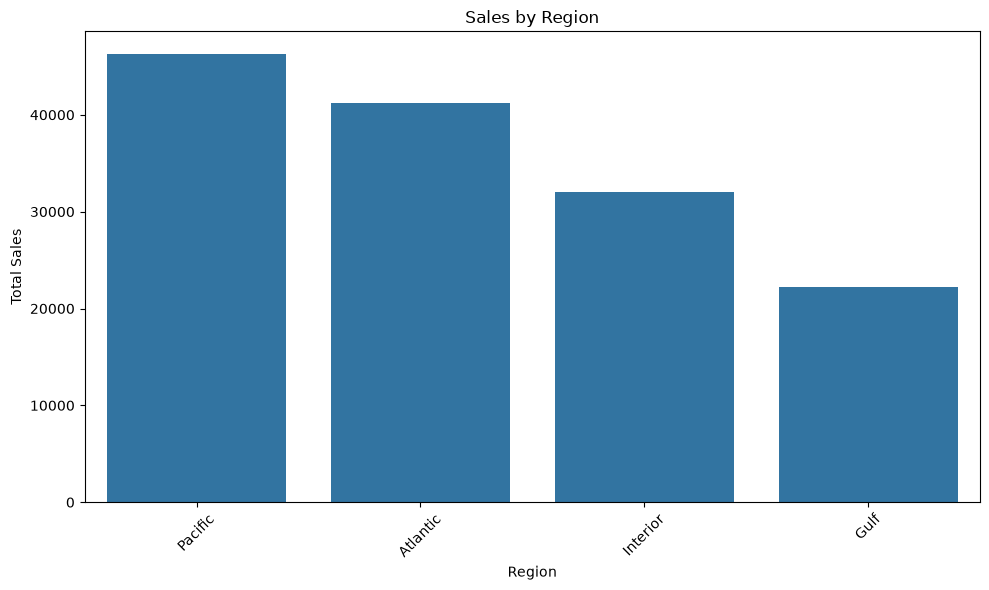

In [39]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_analysis.reset_index(),
    x='Region',
    y='Sales'
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
region_analysis.round(2)

,Orders,Sales,Units,Gross_Profit,Avg_Lead_Time,Avg_Profit_Margin
Region,,,,,,
Pacific,2744,46301.53,12466,30485.94,1322.19,66.59
Atlantic,2476,41197.24,11159,26973.70,1322.75,66.21
Interior,1979,32037.60,8820,21282.49,1323.09,66.87
Gulf,1350,22247.26,6209,14700.67,1311.37,66.42


In [42]:
ship_mode_analysis = analysis_df.groupby('Ship Mode').agg(
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Units=('Units', 'sum'),
    Gross_Profit=('Gross Profit', 'sum'),
    Avg_Lead_Time=('Lead Time', 'mean')
).sort_values('Sales', ascending=False)

ship_mode_analysis.round(2)

,Orders,Sales,Units,Gross_Profit,Avg_Lead_Time
Ship Mode,,,,,
Standard Class,5142,85490.35,23409,56424.46,1314.33
Second Class,1653,27860.22,7546,18306.52,1323.85
First Class,1312,21319.39,5724,14011.09,1338.28
Same Day,442,7113.67,1975,4700.73,1333.44


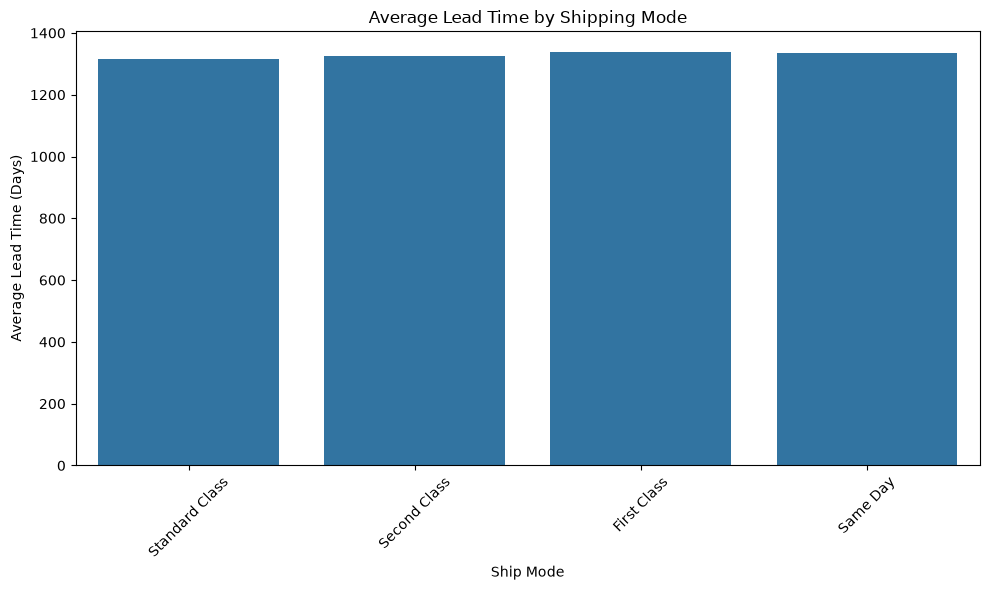

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=ship_mode_analysis.reset_index(),
    x='Ship Mode',
    y='Avg_Lead_Time'
)

plt.title('Average Lead Time by Shipping Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Average Lead Time (Days)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
ship_mode_analysis.round(2)

,Orders,Sales,Units,Gross_Profit,Avg_Lead_Time
Ship Mode,,,,,
Standard Class,5142,85490.35,23409,56424.46,1314.33
Second Class,1653,27860.22,7546,18306.52,1323.85
First Class,1312,21319.39,5724,14011.09,1338.28
Same Day,442,7113.67,1975,4700.73,1333.44


In [45]:
product_analysis = analysis_df.groupby('Product Name').agg(
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Units=('Units', 'sum'),
    Gross_Profit=('Gross Profit', 'sum'),
    Avg_Lead_Time=('Lead Time', 'mean'),
    Avg_Profit_Margin=('Profit Margin %', 'mean')
).sort_values('Sales', ascending=False)

product_analysis.head(15).round(2)

,Orders,Sales,Units,Gross_Profit,Avg_Lead_Time,Avg_Profit_Margin
Product Name,,,,,,
Wonka Bar - Triple Dazzle Caramel,1677,28485.00,7596,18610.20,1325.66,65.33
Wonka Bar -Scrumdiddlyumptious,1704,27874.80,7743,19357.50,1320.64,69.44
Wonka Bar - Milk Chocolate,1768,26867.75,8267,17443.37,1316.76,64.92
Wonka Bar - Fudge Mallows,1527,24890.40,6914,16593.60,1314.24,66.67
Wonka Bar - Nutty Crunch Surprise,1529,23574.95,6755,16819.95,1328.92,71.35
Lickable Wallpaper,92,7860.00,393,3930.00,1339.14,50.00
Kazookles,94,1205.75,371,92.75,1272.99,7.69
Wonka Gum,118,597.50,478,310.70,1306.53,52.00
Everlasting Gobstopper,3,130.00,13,104.00,1394.67,80.00


In [46]:
product_analysis.sort_values(
    'Gross_Profit',
    ascending=False
).head(15).round(2)

,Orders,Sales,Units,Gross_Profit,Avg_Lead_Time,Avg_Profit_Margin
Product Name,,,,,,
Wonka Bar -Scrumdiddlyumptious,1704,27874.80,7743,19357.50,1320.64,69.44
Wonka Bar - Triple Dazzle Caramel,1677,28485.00,7596,18610.20,1325.66,65.33
Wonka Bar - Milk Chocolate,1768,26867.75,8267,17443.37,1316.76,64.92
Wonka Bar - Nutty Crunch Surprise,1529,23574.95,6755,16819.95,1328.92,71.35
Wonka Bar - Fudge Mallows,1527,24890.40,6914,16593.60,1314.24,66.67
Lickable Wallpaper,92,7860.00,393,3930.00,1339.14,50.00
Wonka Gum,118,597.50,478,310.70,1306.53,52.00
Everlasting Gobstopper,3,130.00,13,104.00,1394.67,80.00
Kazookles,94,1205.75,371,92.75,1272.99,7.69


In [47]:
product_analysis.sort_values(
    'Avg_Lead_Time',
    ascending=False
).head(15).round(2)

,Orders,Sales,Units,Gross_Profit,Avg_Lead_Time,Avg_Profit_Margin
Product Name,,,,,,
Hair Toffee,4,76.50,17,59.50,1455.25,77.78
Everlasting Gobstopper,3,130.00,13,104.00,1394.67,80.00
SweeTARTS,10,61.50,41,28.70,1383.50,46.67
Laffy Taffy,10,53.73,27,33.48,1383.10,62.31
Lickable Wallpaper,92,7860.00,393,3930.00,1339.14,50.00
Wonka Bar - Nutty Crunch Surprise,1529,23574.95,6755,16819.95,1328.92,71.35
Wonka Bar - Triple Dazzle Caramel,1677,28485.00,7596,18610.20,1325.66,65.33
Wonka Bar -Scrumdiddlyumptious,1704,27874.80,7743,19357.50,1320.64,69.44
Wonka Bar - Milk Chocolate,1768,26867.75,8267,17443.37,1316.76,64.92


In [48]:
categorical_columns = [
    'Ship Mode',
    'Division',
    'Region',
    'Country/Region'
]

for column in categorical_columns:
    print("\n" + "=" * 50)
    print(column)
    print("Unique values:", analysis_df[column].nunique())
    print(analysis_df[column].value_counts())


Ship Mode
Unique values: 4
Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

Division
Unique values: 3
Division
Chocolate    9844
Other         310
Sugar          40
Name: count, dtype: int64

Region
Unique values: 4
Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64

Country/Region
Unique values: 2
Country/Region
United States    9994
Canada            200
Name: count, dtype: int64


In [49]:
division_analysis = analysis_df.groupby('Division').agg(
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Units=('Units', 'sum'),
    Gross_Profit=('Gross Profit', 'sum'),
    Avg_Lead_Time=('Lead Time', 'mean'),
    Avg_Profit_Margin=('Profit Margin %', 'mean')
).sort_values('Sales', ascending=False)

division_analysis.round(2)

,Orders,Sales,Units,Gross_Profit,Avg_Lead_Time,Avg_Profit_Margin
Division,,,,,,
Chocolate,8205,131692.90,37275,88824.62,1321.17,67.46
Other,304,9663.25,1242,4333.45,1306.03,37.67
Sugar,40,427.48,137,284.73,1355.65,57.69


In [50]:
region_division = analysis_df.groupby(
    ['Region', 'Division']
).agg(
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Gross_Profit=('Gross Profit', 'sum'),
    Avg_Lead_Time=('Lead Time', 'mean'),
    Avg_Profit_Margin=('Profit Margin %', 'mean')
).reset_index()

region_division.round(2)

,Region,Division,Orders,Sales,Gross_Profit,Avg_Lead_Time,Avg_Profit_Margin
0,Atlantic,Chocolate,2351,37580.63,25355.29,1322.28,67.42
1,Atlantic,Other,106,3475.50,1537.10,1323.40,36.32
2,Atlantic,Sugar,19,141.11,81.31,1389.26,54.30
3,Gulf,Chocolate,1292,21016.37,14170.93,1311.91,67.45
4,Gulf,Other,52,1143.50,467.50,1306.96,36.86
5,Gulf,Sugar,6,87.39,62.24,1212.17,63.73
6,Interior,Chocolate,1915,30276.11,20442.55,1324.34,67.51
7,Interior,Other,55,1686.75,792.55,1266.20,42.59
8,Interior,Sugar,9,74.74,47.39,1354.44,54.33
9,Pacific,Chocolate,2647,42819.79,28855.85,1322.45,67.45


In [51]:
product_region = analysis_df.groupby(
    ['Product Name', 'Region']
).agg(
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Units=('Units', 'sum'),
    Gross_Profit=('Gross Profit', 'sum'),
    Avg_Lead_Time=('Lead Time', 'mean'),
    Avg_Profit_Margin=('Profit Margin %', 'mean')
).reset_index()

product_region.round(2).head(20)

,Product Name,Region,Orders,Sales,Units,Gross_Profit,Avg_Lead_Time,Avg_Profit_Margin
0,Everlasting Gobstopper,Gulf,1,40.00,4,32.00,1273.00,80.00
1,Everlasting Gobstopper,Interior,1,30.00,3,24.00,1641.00,80.00
2,Everlasting Gobstopper,Pacific,1,60.00,6,48.00,1270.00,80.00
3,Fizzy Lifting Drinks,Atlantic,2,33.75,9,20.25,1455.50,60.00
4,Fizzy Lifting Drinks,Gulf,1,15.00,4,9.00,909.00,60.00
5,Fizzy Lifting Drinks,Interior,2,18.75,5,11.25,1273.50,60.00
6,Fizzy Lifting Drinks,Pacific,1,11.25,3,6.75,1274.00,60.00
7,Fun Dip,Atlantic,1,6.00,4,2.40,1275.00,40.00
8,Fun Dip,Gulf,1,1.50,1,0.60,1272.00,40.00
9,Fun Dip,Interior,1,4.50,3,1.80,1271.00,40.00


In [52]:
product_region_filtered = product_region[
    product_region['Orders'] >= 20
].copy()

print(
    "Product-region combinations with at least 20 orders:",
    len(product_region_filtered)
)

product_region_filtered.head(20).round(2)

Product-region combinations with at least 20 orders: 28


,Product Name,Region,Orders,Sales,Units,Gross_Profit,Avg_Lead_Time,Avg_Profit_Margin
13,Kazookles,Atlantic,36,484.25,149,37.25,1273.11,7.69
16,Kazookles,Pacific,29,341.25,105,26.25,1309.47,7.69
21,Lickable Wallpaper,Atlantic,34,2780.00,139,1390.00,1387.83,50.00
24,Lickable Wallpaper,Pacific,34,2920.00,146,1460.00,1305.53,50.00
29,Wonka Bar - Fudge Mallows,Atlantic,455,7228.80,2008,4819.20,1321.17,66.67
30,Wonka Bar - Fudge Mallows,Gulf,243,3895.20,1082,2596.80,1304.58,66.67
31,Wonka Bar - Fudge Mallows,Interior,348,5742.00,1595,3828.00,1311.57,66.67
32,Wonka Bar - Fudge Mallows,Pacific,481,8024.40,2229,5349.60,1314.43,66.67
33,Wonka Bar - Milk Chocolate,Atlantic,510,7592.00,2336,4928.96,1309.32,64.92
34,Wonka Bar - Milk Chocolate,Gulf,281,4407.00,1356,2861.16,1289.73,64.92


In [53]:
region_product_leadtime = product_region_filtered.pivot_table(
    index='Product Name',
    columns='Region',
    values='Avg_Lead_Time'
)

region_product_leadtime.round(2).head(20)

Region,Atlantic,Gulf,Interior,Pacific
Product Name,,,,
Kazookles,1273.11,NaN,NaN,1309.47
Lickable Wallpaper,1387.83,NaN,NaN,1305.53
Wonka Bar - Fudge Mallows,1321.17,1304.58,1311.57,1314.43
Wonka Bar - Milk Chocolate,1309.32,1289.73,1331.98,1326.02
Wonka Bar - Nutty Crunch Surprise,1360.43,1322.61,1329.85,1304.45
Wonka Bar - Triple Dazzle Caramel,1323.58,1328.67,1316.33,1332.13
Wonka Bar -Scrumdiddlyumptious,1305.37,1314.55,1329.91,1331.28
Wonka Gum,1312.76,1343.69,1260.21,1311.75


In [54]:
best_region_by_product = (
    product_region_filtered
    .loc[
        product_region_filtered.groupby('Product Name')['Avg_Lead_Time'].idxmin()
    ][
        ['Product Name', 'Region', 'Avg_Lead_Time', 'Orders']
    ]
    .rename(columns={
        'Region': 'Best_Region',
        'Avg_Lead_Time': 'Best_Avg_Lead_Time',
        'Orders': 'Best_Region_Orders'
    })
)

best_region_by_product.round(2)

,Product Name,Best_Region,Best_Avg_Lead_Time,Best_Region_Orders
13,Kazookles,Atlantic,1273.11,36
24,Lickable Wallpaper,Pacific,1305.53,34
30,Wonka Bar - Fudge Mallows,Gulf,1304.58,243
34,Wonka Bar - Milk Chocolate,Gulf,1289.73,281
40,Wonka Bar - Nutty Crunch Surprise,Pacific,1304.45,483
43,Wonka Bar - Triple Dazzle Caramel,Interior,1316.33,377
45,Wonka Bar -Scrumdiddlyumptious,Atlantic,1305.37,513
51,Wonka Gum,Interior,1260.21,29


In [55]:
product_baseline = product_region_filtered.groupby(
    'Product Name'
).agg(
    Current_Avg_Lead_Time=('Avg_Lead_Time', 'mean'),
    Total_Orders=('Orders', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Gross_Profit', 'sum')
).reset_index()

In [57]:
optimization_summary = product_baseline.merge(
    best_region_by_product,
    on='Product Name',
    how='left'
)

In [58]:
optimization_summary['Lead_Time_Reduction_Days'] = (
    optimization_summary['Current_Avg_Lead_Time']
    - optimization_summary['Best_Avg_Lead_Time']
)

optimization_summary['Lead_Time_Reduction_%'] = np.where(
    optimization_summary['Current_Avg_Lead_Time'] != 0,
    (
        optimization_summary['Lead_Time_Reduction_Days']
        / optimization_summary['Current_Avg_Lead_Time']
    ) * 100,
    0
)

In [59]:
optimization_summary.sort_values(
    'Lead_Time_Reduction_%',
    ascending=False
).round(2)

,Product Name,Current_Avg_Lead_Time,Total_Orders,Total_Sales,Total_Profit,Best_Region,Best_Avg_Lead_Time,Best_Region_Orders,Lead_Time_Reduction_Days,Lead_Time_Reduction_%
7,Wonka Gum,1307.10,118,597.50,310.70,Interior,1260.21,29,46.89,3.59
1,Lickable Wallpaper,1346.68,68,5700.00,2850.00,Pacific,1305.53,34,41.15,3.06
4,Wonka Bar - Nutty Crunch Surprise,1329.33,1529,23574.95,16819.95,Pacific,1304.45,483,24.89,1.87
3,Wonka Bar - Milk Chocolate,1314.26,1768,26867.75,17443.37,Gulf,1289.73,281,24.53,1.87
0,Kazookles,1291.29,65,825.50,63.50,Atlantic,1273.11,36,18.18,1.41
6,Wonka Bar -Scrumdiddlyumptious,1320.28,1704,27874.80,19357.50,Atlantic,1305.37,513,14.91,1.13
5,Wonka Bar - Triple Dazzle Caramel,1325.18,1677,28485.00,18610.20,Interior,1316.33,377,8.84,0.67
2,Wonka Bar - Fudge Mallows,1312.94,1527,24890.40,16593.60,Gulf,1304.58,243,8.36,0.64


In [60]:
model_df = analysis_df[
    [
        'Ship Mode',
        'Division',
        'Region',
        'Sales',
        'Units',
        'Gross Profit',
        'Cost',
        'Lead Time'
    ]
].copy()

model_df.head()

,Ship Mode,Division,Region,Sales,Units,Gross Profit,Cost,Lead Time
0,Standard Class,Chocolate,Interior,6.50,2,4.22,2.28,909
1,Standard Class,Chocolate,Interior,7.50,2,4.90,2.60,909
2,Standard Class,Chocolate,Interior,10.47,3,7.47,3.00,909
3,Standard Class,Chocolate,Interior,10.80,3,7.50,3.30,909
4,Standard Class,Chocolate,Atlantic,11.25,3,7.35,3.90,912


In [61]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     10194 non-null  str    
 1   Division      10194 non-null  str    
 2   Region        10194 non-null  str    
 3   Sales         10194 non-null  float64
 4   Units         10194 non-null  int64  
 5   Gross Profit  10194 non-null  float64
 6   Cost          10194 non-null  float64
 7   Lead Time     10194 non-null  int64  
dtypes: float64(3), int64(2), str(3)
memory usage: 923.4 KB


In [62]:
X = model_df.drop('Lead Time', axis=1)
y = model_df['Lead Time']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Lead Time")

Features:
['Ship Mode', 'Division', 'Region', 'Sales', 'Units', 'Gross Profit', 'Cost']

Target:
Lead Time


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [64]:
categorical_features = [
    'Ship Mode',
    'Division',
    'Region'
]

numeric_features = [
    'Sales',
    'Units',
    'Gross Profit',
    'Cost'
]

In [65]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numeric',
            'passthrough',
            numeric_features
        )
    ]
)

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8155
Testing rows: 2039


In [67]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [68]:
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

In [69]:
model_pipeline.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [70]:
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-" * 30)
print(f"MAE  : {mae:.2f} days")
print(f"RMSE : {rmse:.2f} days")
print(f"R²   : {r2:.4f}")

Model Performance
------------------------------
MAE  : 224.81 days
RMSE : 277.15 days
R²   : -0.0861


In [71]:
model_df = analysis_df[
    [
        'Order Date',
        'Product Name',
        'Ship Mode',
        'Division',
        'Region',
        'Sales',
        'Units',
        'Gross Profit',
        'Cost',
        'Lead Time'
    ]
].copy()

model_df['Order Year'] = model_df['Order Date'].dt.year
model_df['Order Month'] = model_df['Order Date'].dt.month

model_df = model_df.drop('Order Date', axis=1)

model_df.head()

,Product Name,Ship Mode,Division,Region,Sales,Units,Gross Profit,Cost,Lead Time,Order Year,Order Month
0,Wonka Bar - Milk Chocolate,Standard Class,Chocolate,Interior,6.50,2,4.22,2.28,909,2024,1
1,Wonka Bar - Triple Dazzle Caramel,Standard Class,Chocolate,Interior,7.50,2,4.90,2.60,909,2024,1
2,Wonka Bar - Nutty Crunch Surprise,Standard Class,Chocolate,Interior,10.47,3,7.47,3.00,909,2024,1
3,Wonka Bar -Scrumdiddlyumptious,Standard Class,Chocolate,Interior,10.80,3,7.50,3.30,909,2024,1
4,Wonka Bar - Triple Dazzle Caramel,Standard Class,Chocolate,Atlantic,11.25,3,7.35,3.90,912,2024,1


In [72]:
X = model_df.drop('Lead Time', axis=1)
y = model_df['Lead Time']

categorical_features = [
    'Product Name',
    'Ship Mode',
    'Division',
    'Region'
]

numeric_features = [
    'Order Year',
    'Order Month',
    'Sales',
    'Units',
    'Gross Profit',
    'Cost'
]

In [73]:
preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numeric',
            'passthrough',
            numeric_features
        )
    ]
)

In [74]:
model_v2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model_pipeline_v2 = Pipeline(
    steps=[
        ('preprocessor', preprocessor_v2),
        ('model', model_v2)
    ]
)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model_pipeline_v2.fit(X_train, y_train)

print("Improved model training completed!")

Improved model training completed!


In [76]:
y_pred_v2 = model_pipeline_v2.predict(X_test)

mae_v2 = mean_absolute_error(y_test, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_v2))
r2_v2 = r2_score(y_test, y_pred_v2)

print("Improved Model Performance")
print("-" * 35)
print(f"MAE  : {mae_v2:.2f} days")
print(f"RMSE : {rmse_v2:.2f} days")
print(f"R²   : {r2_v2:.4f}")

Improved Model Performance
-----------------------------------
MAE  : 179.75 days
RMSE : 203.05 days
R²   : 0.4170


In [77]:
recommendation_df = optimization_summary.copy()

recommendation_df['Lead_Time_Reduction_%'] = (
    recommendation_df['Lead_Time_Reduction_%'].round(2)
)

recommendation_df['Potential_Impact'] = np.where(
    recommendation_df['Lead_Time_Reduction_%'] > 0,
    'Potential Improvement',
    'No Improvement'
)

recommendation_df = recommendation_df.sort_values(
    'Lead_Time_Reduction_%',
    ascending=False
)

recommendation_df[
    [
        'Product Name',
        'Current_Avg_Lead_Time',
        'Best_Region',
        'Best_Avg_Lead_Time',
        'Lead_Time_Reduction_Days',
        'Lead_Time_Reduction_%',
        'Total_Orders',
        'Total_Sales',
        'Total_Profit',
        'Potential_Impact'
    ]
].round(2)

,Product Name,Current_Avg_Lead_Time,Best_Region,Best_Avg_Lead_Time,Lead_Time_Reduction_Days,Lead_Time_Reduction_%,Total_Orders,Total_Sales,Total_Profit,Potential_Impact
7,Wonka Gum,1307.10,Interior,1260.21,46.89,3.59,118,597.50,310.70,Potential Improvement
1,Lickable Wallpaper,1346.68,Pacific,1305.53,41.15,3.06,68,5700.00,2850.00,Potential Improvement
4,Wonka Bar - Nutty Crunch Surprise,1329.33,Pacific,1304.45,24.89,1.87,1529,23574.95,16819.95,Potential Improvement
3,Wonka Bar - Milk Chocolate,1314.26,Gulf,1289.73,24.53,1.87,1768,26867.75,17443.37,Potential Improvement
0,Kazookles,1291.29,Atlantic,1273.11,18.18,1.41,65,825.50,63.50,Potential Improvement
6,Wonka Bar -Scrumdiddlyumptious,1320.28,Atlantic,1305.37,14.91,1.13,1704,27874.80,19357.50,Potential Improvement
5,Wonka Bar - Triple Dazzle Caramel,1325.18,Interior,1316.33,8.84,0.67,1677,28485.00,18610.20,Potential Improvement
2,Wonka Bar - Fudge Mallows,1312.94,Gulf,1304.58,8.36,0.64,1527,24890.40,16593.60,Potential Improvement


In [78]:
recommendation_df['Confidence Score'] = np.minimum(
    recommendation_df['Total_Orders'] / 500,
    1
) * 100

In [79]:
recommendation_df[
    [
        'Product Name',
        'Best_Region',
        'Lead_Time_Reduction_Days',
        'Lead_Time_Reduction_%',
        'Total_Orders',
        'Confidence Score'
    ]
].round(2)

,Product Name,Best_Region,Lead_Time_Reduction_Days,Lead_Time_Reduction_%,Total_Orders,Confidence Score
7,Wonka Gum,Interior,46.89,3.59,118,23.6
1,Lickable Wallpaper,Pacific,41.15,3.06,68,13.6
4,Wonka Bar - Nutty Crunch Surprise,Pacific,24.89,1.87,1529,100.0
3,Wonka Bar - Milk Chocolate,Gulf,24.53,1.87,1768,100.0
0,Kazookles,Atlantic,18.18,1.41,65,13.0
6,Wonka Bar -Scrumdiddlyumptious,Atlantic,14.91,1.13,1704,100.0
5,Wonka Bar - Triple Dazzle Caramel,Interior,8.84,0.67,1677,100.0
2,Wonka Bar - Fudge Mallows,Gulf,8.36,0.64,1527,100.0


In [80]:
def recommendation_category(row):
    if row['Confidence Score'] >= 70 and row['Lead_Time_Reduction_%'] >= 1:
        return 'Strong Scenario'
    elif row['Confidence Score'] >= 40 and row['Lead_Time_Reduction_%'] >= 1:
        return 'Moderate Scenario'
    elif row['Lead_Time_Reduction_%'] > 0:
        return 'Low-Confidence Scenario'
    else:
        return 'No Improvement'

recommendation_df['Recommendation'] = recommendation_df.apply(
    recommendation_category,
    axis=1
)

In [81]:
recommendation_df[
    [
        'Product Name',
        'Best_Region',
        'Lead_Time_Reduction_Days',
        'Lead_Time_Reduction_%',
        'Confidence Score',
        'Recommendation'
    ]
].round(2)

,Product Name,Best_Region,Lead_Time_Reduction_Days,Lead_Time_Reduction_%,Confidence Score,Recommendation
7,Wonka Gum,Interior,46.89,3.59,23.6,Low-Confidence Scenario
1,Lickable Wallpaper,Pacific,41.15,3.06,13.6,Low-Confidence Scenario
4,Wonka Bar - Nutty Crunch Surprise,Pacific,24.89,1.87,100.0,Strong Scenario
3,Wonka Bar - Milk Chocolate,Gulf,24.53,1.87,100.0,Strong Scenario
0,Kazookles,Atlantic,18.18,1.41,13.0,Low-Confidence Scenario
6,Wonka Bar -Scrumdiddlyumptious,Atlantic,14.91,1.13,100.0,Strong Scenario
5,Wonka Bar - Triple Dazzle Caramel,Interior,8.84,0.67,100.0,Low-Confidence Scenario
2,Wonka Bar - Fudge Mallows,Gulf,8.36,0.64,100.0,Low-Confidence Scenario


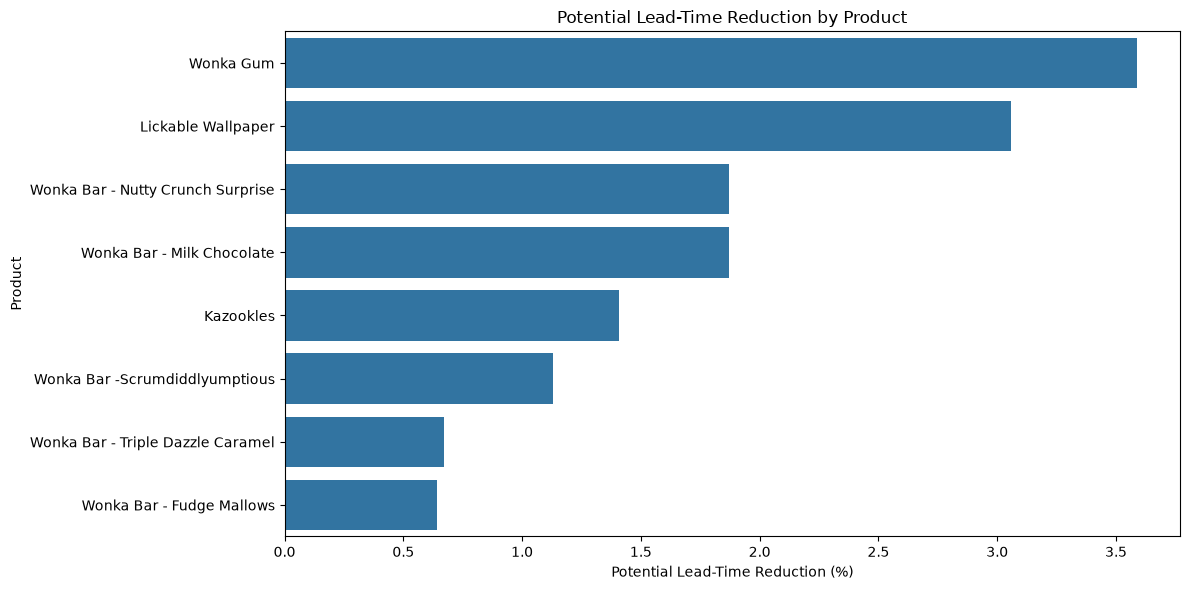

In [82]:
top_recommendations = recommendation_df.sort_values(
    'Lead_Time_Reduction_%',
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_recommendations,
    x='Lead_Time_Reduction_%',
    y='Product Name'
)

plt.title('Potential Lead-Time Reduction by Product')
plt.xlabel('Potential Lead-Time Reduction (%)')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [83]:
recommendation_df.to_csv(
    'regional_reallocation_recommendations.csv',
    index=False
)

print("Recommendation file saved successfully!")

Recommendation file saved successfully!


In [84]:
product_region_filtered.to_csv(
    'product_region_analysis.csv',
    index=False
)

print("Product-region analysis saved successfully!")

Product-region analysis saved successfully!


In [85]:
kpi_summary = {
    'Total Orders': analysis_df['Order ID'].nunique(),
    'Total Sales': analysis_df['Sales'].sum(),
    'Total Units': analysis_df['Units'].sum(),
    'Total Gross Profit': analysis_df['Gross Profit'].sum(),
    'Average Lead Time': analysis_df['Lead Time'].mean(),
    'Average Profit Margin': analysis_df['Profit Margin %'].mean(),
    'Model MAE': mae_v2,
    'Model RMSE': rmse_v2,
    'Model R2': r2_v2
}

kpi_summary

{'Total Orders': 8549,
 'Total Sales': np.float64(141783.63),
 'Total Units': np.int64(38654),
 'Total Gross Profit': np.float64(93442.79999999999),
 'Average Lead Time': np.float64(1320.8418677653522),
 'Average Profit Margin': np.float64(66.51404480694819),
 'Model MAE': 179.74897372585002,
 'Model RMSE': np.float64(203.0457101054333),
 'Model R2': 0.4170367815735666}

In [86]:
kpi_df = pd.DataFrame(
    [kpi_summary]
)

kpi_df.round(2)

,Total Orders,Total Sales,Total Units,Total Gross Profit,Average Lead Time,Average Profit Margin,Model MAE,Model RMSE,Model R2
0,8549,141783.63,38654,93442.8,1320.84,66.51,179.75,203.05,0.42


In [87]:
import joblib

joblib.dump(
    model_pipeline_v2,
    'lead_time_prediction_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!
